In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import joblib

In [4]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [5]:
from core.semantic_similarity_check.utils import init_random_seed
from core.data_preparation.visualization import *
from core.data_preparation.utils import *
from core.detection_model_building.nlp import *
from core.detection_model_building.classic_models_training import *

In [6]:
SEED = 316

In [7]:
init_random_seed(SEED)

In [8]:
data_path = "data"

In [9]:
data = pd.read_csv(f"{data_path}/out/final_hallucination_detection_dataset.csv", index_col=0)
data.sample(5)

,Prompt,completion_tokens,Answer,token_logprobs,finish_reason,hallucination_score,similarity_score,mean_logprob,median_logprob,min_logprob,max_logprob,std_logprob,low_logprob_frac,normalized_entropy_logprob,target_score,target
24264,[INST] You are an AI assistant. You will be gi...,154,"A lot of fun if you like that sort of thing, ...",[-3.02137678e+00 -3.26603186e+00 -8.23679357e-...,stop,0.1875,0.820697,-0.528057,-0.115947,-3.874361,-2.903514e-08,0.828881,0.0,0.974688,0.184221,0.0
54742,[INST] You are an AI assistant. You will be gi...,5,"""immune system""",[-3.38814321e+00 -4.94626385e-01 -2.68412647e-...,stop,0.0000,0.871128,-1.115564,-0.494626,-3.388143,-2.684126e-05,1.294189,0.0,0.805575,0.051549,0.0
32826,[INST] You are an AI assistant. You will be gi...,141,\n\nTo determine whether the premise entails ...,[-1.19771140e+00 -8.27373634e-03 -3.67017848e-...,stop,0.1500,0.945912,-0.478253,-0.074613,-4.946222,-1.857634e-07,0.824420,0.0,0.977844,0.111635,0.0
26274,[INST] You are an AI assistant. User will you ...,8,B: The Mystery of Human Life,[-1.66055529e+00 -1.10536225e-01 -3.01246872e-...,stop,0.7850,0.597870,-0.222654,-0.002935,-1.660555,-8.453821e-06,0.544644,0.0,0.969790,0.631852,1.0
14731,[INST] You are an AI assistant. User will you ...,29,":\nSince 2000, he has been a performer in the ...",[-1.17894865e-01 -5.23264418e-01 -1.32968910e+...,stop,0.0250,0.697921,-0.201890,-0.035019,-1.329689,-5.842751e-06,0.340926,0.0,0.989553,0.135832,0.0


In [10]:
data_preprocessed = data.copy()

In [11]:
data_preprocessed['length_exceeded'] = (data_preprocessed['finish_reason'] == "length").astype(int)
data_preprocessed.drop(columns="finish_reason", axis=1, inplace=True)
data_preprocessed.sample(10)

,Prompt,completion_tokens,Answer,token_logprobs,hallucination_score,similarity_score,mean_logprob,median_logprob,min_logprob,max_logprob,std_logprob,low_logprob_frac,normalized_entropy_logprob,target_score,target,length_exceeded
45816,[INST] You are an AI assistant. You will be gi...,3,Komo River,[-2.74947490e+00 -1.19970352e-03 -1.85137113e-01],0.05000,0.713220,-0.978604,-0.185137,-2.749475,-1.199704e-03,1.254444,0.00000,0.740294,0.144712,0.0,0
14670,[INST] You are an AI assistant. You will be gi...,73,"On a scale of 1-5, I would rate this review a...",[-2.79450808e+00 -1.17153377e-02 -1.51031236e-...,0.78235,0.851660,-0.292742,-0.011715,-2.794508,-3.746828e-07,0.580585,0.00000,0.983305,0.528746,1.0,0
52322,[INST] You are an AI assistant. You will be gi...,76,"\n\nIn conclusion, while the sentence is techn...",[-1.11565055e+00 -1.87185040e-01 -2.57733730e+...,0.25781,0.943281,-0.560958,-0.142544,-2.577337,-6.311721e-07,0.724700,0.00000,0.967465,0.177374,0.0,0
29711,"[INST] You are a helpful assistant, who always...",19,It's important to fix things when they're bro...,[-2.15101812e+00 -3.54530953e-01 -2.99660292e-...,0.78234,0.498958,-0.706143,-0.413161,-2.288723,-7.592811e-04,0.705832,0.00000,0.953170,0.669821,1.0,0
43525,"[INST] You are a teacher. Given a task, you ex...",431,"So, it seems that the comment is asking me to...",[-2.22157161e+00 -5.40568004e-01 -4.31205203e+...,0.15000,0.896503,-0.719453,-0.305947,-5.185204,-4.015211e-06,0.979263,0.00232,0.971339,0.131399,0.0,0
3033,"[INST] You are a helpful assistant, who always...",61,:\n\n* Țineți-vă de la scrie în scris.\n\nI am...,[-1.55373267e-01 -5.09098539e-01 -4.86282380e-...,0.95200,0.687862,-1.035293,-0.507343,-4.390603,-2.057156e-04,1.233895,0.00000,0.935900,0.696055,1.0,0
15925,"[INST] You are a helpful assistant, who always...",1,1,[-1.95639828],0.98457,0.500134,-1.956398,-1.956398,-1.956398,-1.956398e+00,0.000000,0.00000,0.000000,0.790688,1.0,0
13741,[INST] You are an AI assistant. You will be gi...,290,\n\nThe movie I recently watched was truly fan...,[-9.50062159e-02 -4.63489220e-01 -1.31335392e+...,0.68000,0.731475,-0.208096,-0.007394,-2.964357,-2.349110e-08,0.447682,0.00000,0.992123,0.515410,1.0,0
31198,question:Please answer the following question:...,10,"No. The correct answer is ""lonely"".",[-4.16312538e-01 -1.47152727e+00 -3.65494468e-...,0.95000,0.682521,-0.670020,-0.380435,-2.739630,-7.414536e-05,0.850943,0.00000,0.930166,0.696992,1.0,0
47794,[INST] You are an AI assistant that follows in...,71,Tristram of Lyonesse is a character in the Ar...,[-6.25841830e-01 -7.34548977e-04 -1.30614199e-...,0.78235,0.865045,-0.396368,-0.235219,-1.679650,-1.286226e-05,0.458526,0.00000,0.983408,0.523392,1.0,0


In [12]:
data_preprocessed['prompt_tokenized'] = data_preprocessed['Prompt'].apply(tokenize_with_mistral)
data_preprocessed['answer_tokenized'] = data_preprocessed['Answer'].apply(tokenize_with_mistral)

data_preprocessed.sample(5)

,Prompt,completion_tokens,Answer,token_logprobs,hallucination_score,similarity_score,mean_logprob,median_logprob,min_logprob,max_logprob,std_logprob,low_logprob_frac,normalized_entropy_logprob,target_score,target,length_exceeded,prompt_tokenized,answer_tokenized
943,"[INST] You are a helpful assistant, who always...",11,"""Stejné jako tlačítka""",[-1.73819291e+00 -1.28612783e+00 -1.11586675e-...,0.01000,0.986930,-0.395762,-0.095137,-1.738193,-0.001116,0.553918,0.0,0.965339,0.011228,0.0,0,"[▁[, INST, ], ▁You, ▁are, ▁a, ▁helpful, ▁assis...","[▁"", Ste, j, né, ▁jako, ▁t, la, č, ít, ka, ""]"
28801,question:Title: Arrived Broken! Review: Let me...,1,A,[-1.59099199],0.00000,0.779032,-1.590992,-1.590992,-1.590992,-1.590992,0.000000,0.0,0.000000,0.088387,0.0,0,"[▁question, :, Title, :, ▁Ar, rived, ▁Bro, ken...",[▁A]
58503,[INST] You are an AI assistant. You will be gi...,36,\n\n You can create and edit levels a...,[-1.35802998e-01 -2.40165263e-01 -4.62461083e+...,0.12345,0.921650,-0.567446,-0.067621,-4.624611,-0.000010,1.070543,0.0,0.963227,0.105410,0.0,0,"[▁[, INST, ], ▁You, ▁are, ▁an, ▁AI, ▁assistant...","[▁, <0x0A>, <0x0A>, ▁▁▁▁▁▁▁▁▁, ▁You, ▁can, ▁cr..."
56137,[INST] You are an AI assistant. You will be gi...,23,"\nThe Eagle, an eatType restaurant with a hig...",[-2.04571575e+00 -4.77415530e-03 -2.66501568e+...,0.12345,0.966724,-0.398776,-0.027613,-2.665016,-0.000002,0.726684,0.0,0.967390,0.087381,0.0,0,"[▁[, INST, ], ▁You, ▁are, ▁an, ▁AI, ▁assistant...","[▁, <0x0A>, The, ▁E, agle, ,, ▁an, ▁eat, Type,..."
53478,[INST] You are an AI assistant that helps peop...,3,40.,[-3.30048718 -2.47489672 -3.4209908 ],1.00000,0.554628,-3.065458,-3.300487,-3.420991,-2.474897,0.420478,0.0,0.911505,0.778149,1.0,0,"[▁[, INST, ], ▁You, ▁are, ▁an, ▁AI, ▁assistant...","[▁, 4, 0, .]"


In [13]:
data_preprocessed.drop(columns=['hallucination_score', 'similarity_score', 'target_score', 'Prompt', 'Answer', 'token_logprobs'], 
                       inplace=True)
data_preprocessed.sample(5)

,completion_tokens,mean_logprob,median_logprob,min_logprob,max_logprob,std_logprob,low_logprob_frac,normalized_entropy_logprob,target,length_exceeded,prompt_tokenized,answer_tokenized
47872,124,-0.279424,-0.023384,-1.952161,-5.712682e-08,0.420608,0.0,0.988719,0.0,0,"[▁[, INST, ], ▁You, ▁are, ▁an, ▁AI, ▁assistant...","[▁, <0x0A>, <0x0A>, ▁▁▁▁▁▁▁, ▁No, ,, ▁we, ▁can..."
46736,87,-0.666753,-0.274459,-4.124420,-1.012806e-06,0.842533,0.0,0.963923,0.0,0,"[▁[, INST, ], ▁You, ▁are, ▁an, ▁AI, ▁assistant...","[▁, <0x0A>, <0x0A>, The, ▁sentences, ▁are, ▁no..."
12747,106,-0.707753,-0.240512,-3.741824,-5.927318e-06,0.942112,0.0,0.962977,0.0,0,"[▁[, INST, ], ▁You, ▁are, ▁an, ▁AI, ▁assistant...","[▁, 1, ., ▁G, ather, ▁more, ▁information, ▁abo..."
46361,65,-0.712506,-0.273947,-4.132596,-1.299895e-06,0.953163,0.0,0.958923,0.0,0,"[▁[, INST, ], ▁You, ▁are, ▁an, ▁AI, ▁assistant...","[▁It, ', s, ▁time, ▁to, ▁switch, ▁up, ▁your, ▁..."
37103,12,-1.062675,-0.668990,-3.650114,-2.527196e-03,1.170484,0.0,0.897571,1.0,0,"[▁[, INST, ], ▁You, ▁are, ▁an, ▁AI, ▁assistant...","[▁, <0x0A>, ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁, ▁▁▁▁▁▁▁▁▁▁, ▁"", ..."


In [14]:
X, y = divide_data(data_preprocessed, 'target')

In [15]:
def identity(x):
    return x

In [16]:
tfidf_vectorizer_preprocessor = Pipeline([
    (
        'vectorizer',
        ColumnTransformer([
            ('prompt_vectorizer', TfidfVectorizer(analyzer=identity, min_df=50, dtype=np.float32), 'prompt_tokenized'),
            ('answer_vectorizer', TfidfVectorizer(analyzer=identity, min_df=50, dtype=np.float32), 'answer_tokenized')
        ], remainder='passthrough', verbose_feature_names_out=True)
    )
])

tfidf_vectorizer_preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('prompt_vectorizer', ...), ('answer_vectorizer', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [17]:
classifier = RandomForestClassifier(random_state=SEED)
classifier

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
hallucinations_detection_pipeline = Pipeline([
    ("preprocessor", tfidf_vectorizer_preprocessor),
    ("model", classifier)
])

hallucinations_detection_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator

In [19]:
search = HalvingGridSearchCV(
    estimator=hallucinations_detection_pipeline,
    param_grid={
        "model__n_estimators": [20, 50, 100, 300],
        "model__max_depth": [None, 5, 10, 20],
        "model__criterion": ["gini", "entropy", "log_loss"]
    },
    cv=5,
    scoring="roc_auc",
    factor=2,
    n_jobs=-1,
    random_state=SEED,
    refit=True,
    verbose=1
)

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 1709
max_resources_: 54703
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 48
n_resources: 1709
Fitting 5 folds for each of 48 candidates, totalling 240 fits
----------
iter: 1
n_candidates: 24
n_resources: 3418
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------
iter: 2
n_candidates: 12
n_resources: 6836
Fitting 5 folds for each of 12 candidates, totalling 60 fits
----------
iter: 3
n_candidates: 6
n_resources: 13672
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 4
n_candidates: 3
n_resources: 27344
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 5
n_candidates: 2
n_resources: 54688
Fitting 5 folds for each of 2 candidates, totalling 10 fits


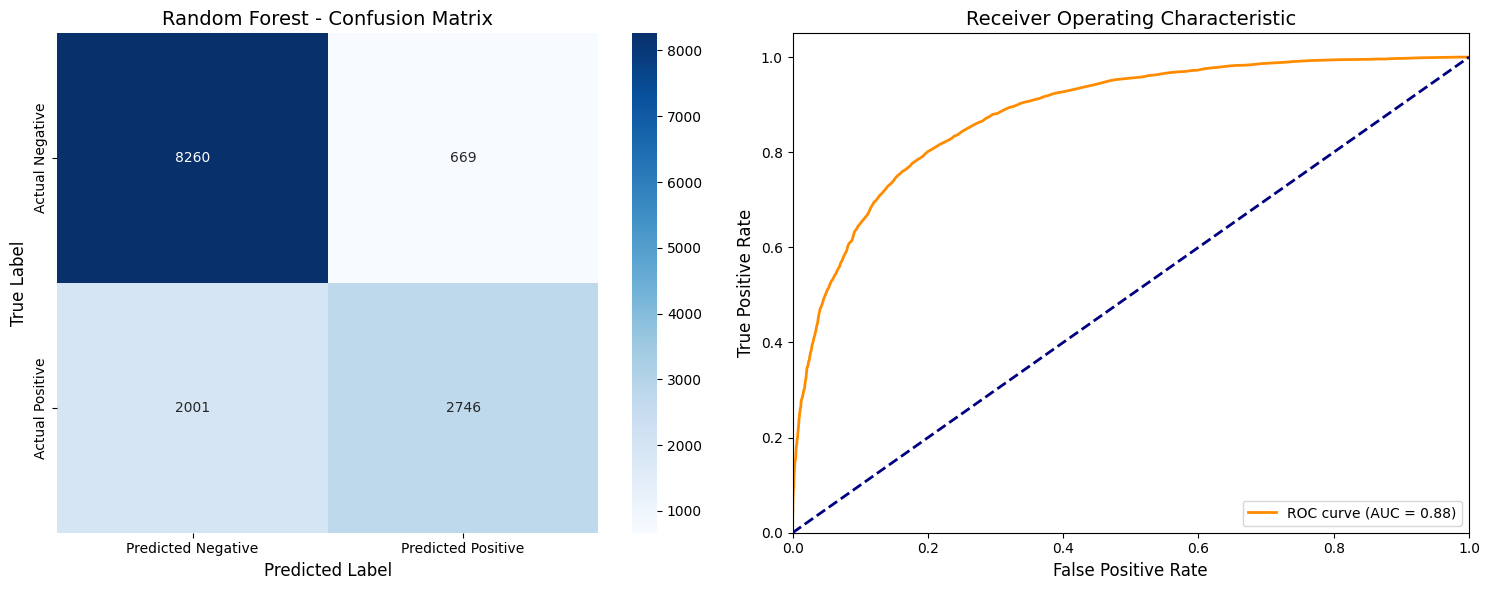

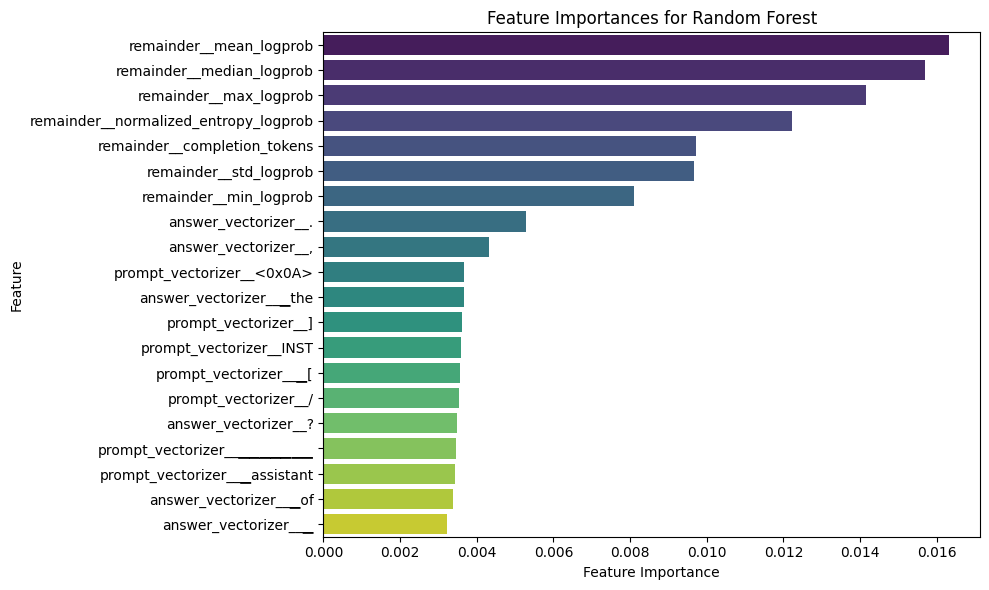

ROC-AUC на тестовой выборке: 0.8823117337218455
Лучшие гиперпараметры: {'model__criterion': 'gini', 'model__max_depth': None, 'model__n_estimators': 300}


In [20]:
result = tune_classification_model_with_search(
    search=search,
    X=X,
    y=y,
    test_size=0.2,
    seed=SEED,
    model_name="Random Forest"
)

print("ROC-AUC на тестовой выборке:", result["metrics"].roc_auc)
print("Лучшие гиперпараметры:", result["search"].best_params_)

In [21]:
best_pipeline = result['best_pipeline']
best_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator

In [22]:
result['metrics'].to_compact_dict()

{'ROC AUC': 0.8823117337218455,
 'F1 Score': 0.7668696646938066,
 'Precision': 0.8045446639202896,
 'Recall': 0.7517731046950614,
 'Accuracy': 0.8047674758701374,
 'Training Time (s)': 1463.5598118305206}

In [23]:
joblib.dump(best_pipeline, "models/hallucinations_detection_pipeline.pkl")

['models/hallucinations_detection_pipeline.pkl']